# Verification 2: Does ISOMAP Actually Beat PCA for Stress Detection?

The cross-over test showed ISOMAP and PCA capture similar Euclidean variance at 2D (~77% each). But the original notebook's stress detection claim is a different question entirely: **when you embed calm data and then project stress data into the same 2D space, which method puts more stress points further from the calm cloud?**

This is not a compression quality question. It is a **geometric separation** question.

The intuition: if ISOMAP's geodesic structure gives it a more "stretched out" representation of the calm manifold, anomalous stress states might land further outside it — even if both methods capture the same total variance.

## Three Methods Compared

| Method | What it optimises | How OOS projection works |
|--------|-------------------|--------------------------|
| **PCA** | Euclidean variance in training data | Linear projection: `Z = (X - mean) @ components.T` |
| **ISOMAP** | Geodesic distance preservation | Nyström extension: approximate new point's geodesic distances |
| **UMAP** | Topological neighbourhood structure | Trained transform: `umap_model.transform(X_new)` |

For each method we measure:
1. **Separation score** — KS test statistic between calm and stress distance distributions (higher = better separation)
2. **% stress bars flagged** — fraction of stress bars above the calm 95th percentile distance threshold
3. **Depth profile** — how cleanly each axis correlates with individual OBI levels (interpretability)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr, ks_2samp
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
import umap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

LOB_DIR  = 'data/lob'
OBI_COLS = [f'obi_{k:02d}' for k in range(10)]
METHODS  = ['PCA', 'ISOMAP', 'UMAP']
COLORS   = {'PCA': '#4472C4', 'ISOMAP': '#E74C3C', 'UMAP': '#2ECC71'}

def build_obi_bars(path):
    df = pd.read_parquet(path)
    df.index = pd.DatetimeIndex(df.index).tz_convert('America/New_York')
    mh = df.between_time('09:30', '16:00')
    frames = {}
    for k in range(10):
        b = mh[f'bid_sz_{k:02d}'].astype(np.int64)
        a = mh[f'ask_sz_{k:02d}'].astype(np.int64)
        denom = (b + a).replace(0, np.nan)
        frames[f'obi_{k:02d}'] = ((b - a) / denom).resample('1min').mean()
    frames['mid'] = ((mh['bid_px_00'] + mh['ask_px_00']) / 2).resample('1min').last()
    out = pd.DataFrame(frames).dropna()
    out['ret_fwd'] = out['mid'].pct_change().shift(-1)
    return out.dropna()

# Load calm (full Oct 2023) and stress (Aug 2024)
print('Loading data...')
calm   = build_obi_bars(f'{LOB_DIR}/lob_mbp10_NVDA_oct2023_full.parquet')
stress = build_obi_bars(f'{LOB_DIR}/lob_mbp10_NVDA_stress_aug2024.parquet')

X_calm   = calm[OBI_COLS].values
X_stress = stress[OBI_COLS].values

print(f'Calm  : {len(X_calm):,} bars  ({calm.index.min().date()} -> {calm.index.max().date()})')
print(f'Stress: {len(X_stress):,} bars  ({stress.index.min().date()} -> {stress.index.max().date()})')


/Users/harold/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...


Calm  : 8,579 bars  (2023-10-02 -> 2023-10-31)
Stress: 1,949 bars  (2024-08-05 -> 2024-08-09)


## Fitting All Three Models on Calm Training Data

All three models are trained **only on calm Oct 2023 data**. The stress Aug 2024 data is projected using each model's OOS transform — no retraining.

This is the key: the "calm manifold" is the reference. We then ask how far stress bars land from it.


In [2]:
# Fit all three models on calm data
print('Fitting PCA...')
pca = PCA(n_components=2)
Z_pca_calm = pca.fit_transform(X_calm)
Z_pca_stress = pca.transform(X_stress)
print(f'  PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

print('Fitting ISOMAP...')
iso = Isomap(n_components=2, n_neighbors=15)
Z_iso_calm = iso.fit_transform(X_calm)
Z_iso_stress = iso.transform(X_stress)
print(f'  ISOMAP reconstruction error: {iso.reconstruction_error():.4f}')

print('Fitting UMAP...')
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=42, transform_seed=42)
Z_umap_calm = umap_model.fit_transform(X_calm)
Z_umap_stress = umap_model.transform(X_stress)
print('  UMAP done.')

EMBEDDINGS = {
    'PCA'   : (Z_pca_calm,   Z_pca_stress),
    'ISOMAP': (Z_iso_calm,   Z_iso_stress),
    'UMAP'  : (Z_umap_calm,  Z_umap_stress),
}
print('\nAll models fitted.')


Fitting PCA...
  PCA variance explained: 78.4%
Fitting ISOMAP...


  ISOMAP reconstruction error: 0.0278
Fitting UMAP...


  UMAP done.

All models fitted.


## Test 1: Stress Separation Quality

For each method, we compute the Euclidean distance from every bar (calm and stress) to the centroid of the calm training cloud. Then:

- **KS statistic**: how different are the calm and stress distance distributions? (0=identical, 1=perfectly separated)
- **% flagged**: fraction of stress bars above the calm 95th percentile threshold
- **Cohen's d**: standardised mean difference between stress and calm distances

A good stress detector should push stress bars far from the calm centroid.


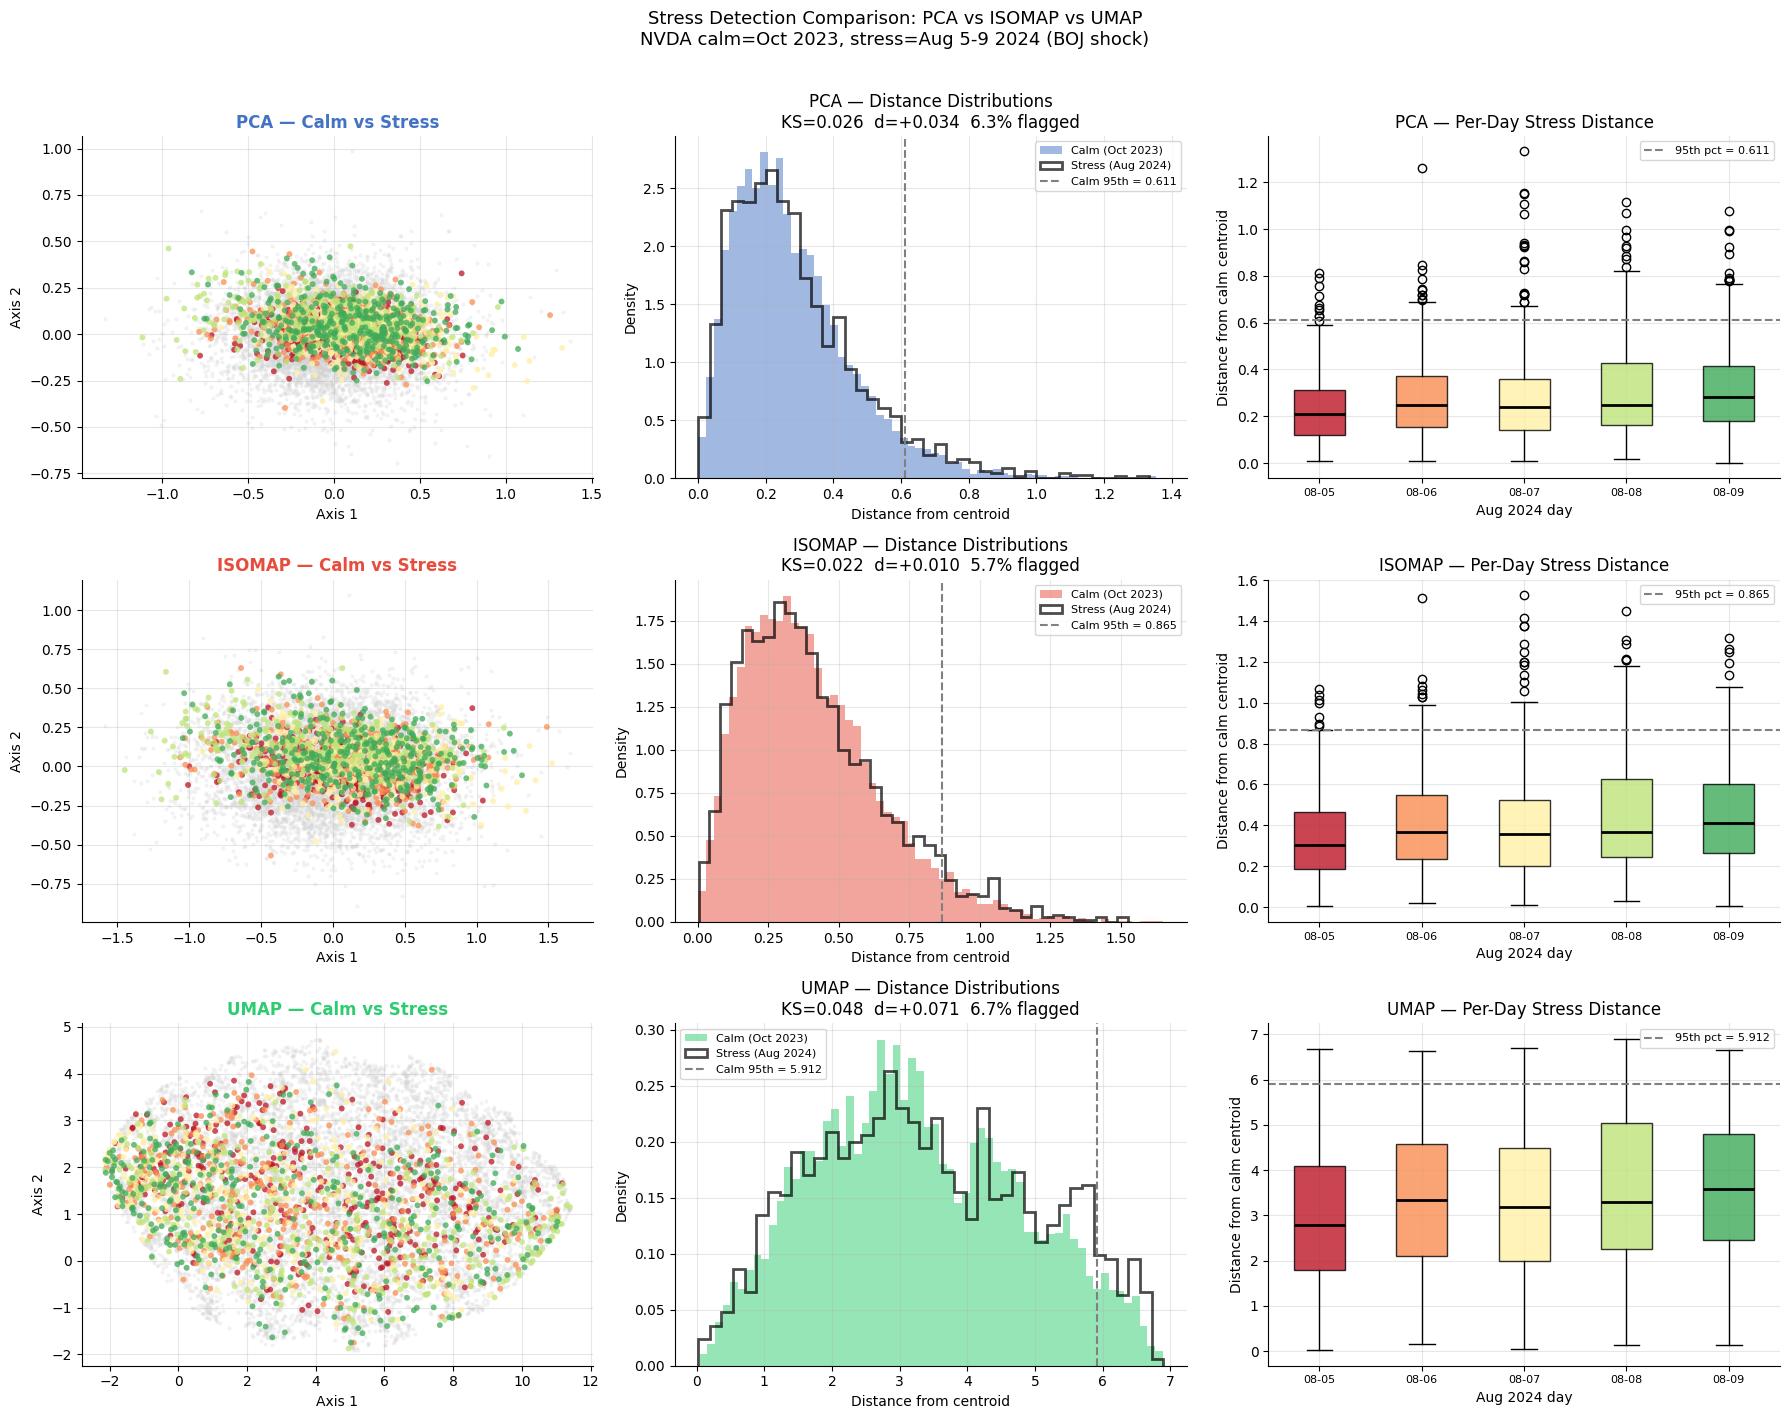

Method     KS stat    KS p-val   % flagged    Cohen d
-------------------------------------------------------
PCA          0.026    2.16e-01        6.3%     +0.034  *
ISOMAP       0.022    4.25e-01        5.7%     +0.010  *
UMAP         0.048    1.20e-03        6.7%     +0.071  *


In [3]:
stress_dates = stress.index.date
unique_dates = sorted(set(stress_dates))
n_days = len(unique_dates)
day_colors = plt.cm.RdYlGn(np.linspace(0.05, 0.85, n_days))
date_cmap  = {d: day_colors[i] for i, d in enumerate(unique_dates)}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

separation = {}

for row, (method, (Z_calm, Z_stress)) in enumerate(EMBEDDINGS.items()):
    centroid = Z_calm.mean(axis=0)

    calm_dists   = np.linalg.norm(Z_calm   - centroid, axis=1)
    stress_dists = np.linalg.norm(Z_stress - centroid, axis=1)
    p95 = np.percentile(calm_dists, 95)

    ks_stat, ks_pval = ks_2samp(calm_dists, stress_dists)
    pct_flagged = (stress_dists > p95).mean() * 100
    cohens_d = (stress_dists.mean() - calm_dists.mean()) / calm_dists.std()

    separation[method] = dict(ks=ks_stat, ks_pval=ks_pval,
                               pct=pct_flagged, d=cohens_d, p95=p95)

    # Col 0: scatter (calm grey, stress by day)
    ax0 = axes[row, 0]
    ax0.scatter(Z_calm[:, 0], Z_calm[:, 1], c='lightgrey', s=4, alpha=0.2, zorder=0)
    for d in unique_dates:
        mask = stress_dates == d
        ax0.scatter(Z_stress[mask, 0], Z_stress[mask, 1],
                    c=[date_cmap[d]], s=18, alpha=0.75, edgecolors='none', zorder=5)
    ax0.set_title(f'{method} — Calm vs Stress', color=COLORS[method], fontweight='bold')
    ax0.set_xlabel('Axis 1'); ax0.set_ylabel('Axis 2')

    # Col 1: distance distributions
    ax1 = axes[row, 1]
    ax1.hist(calm_dists, bins=60, alpha=0.5, color=COLORS[method],
             density=True, label='Calm (Oct 2023)')
    ax1.hist(stress_dists, bins=40, alpha=0.7, color='black',
             density=True, label='Stress (Aug 2024)', histtype='step', lw=2)
    ax1.axvline(p95, color='grey', ls='--', lw=1.5, label=f'Calm 95th = {p95:.3f}')
    ax1.set_xlabel('Distance from centroid')
    ax1.set_ylabel('Density')
    ax1.set_title(f'{method} — Distance Distributions\nKS={ks_stat:.3f}  d={cohens_d:+.3f}  {pct_flagged:.1f}% flagged')
    ax1.legend(fontsize=8)

    # Col 2: per-day box plot
    ax2 = axes[row, 2]
    day_dists = [stress_dists[stress_dates == d] for d in unique_dates]
    bp = ax2.boxplot(day_dists, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', lw=2))
    for patch, d in zip(bp['boxes'], unique_dates):
        patch.set_facecolor(date_cmap[d]); patch.set_alpha(0.8)
    ax2.axhline(p95, color='grey', ls='--', lw=1.5, label=f'95th pct = {p95:.3f}')
    ax2.set_xticklabels([str(d)[5:] for d in unique_dates], fontsize=8)
    ax2.set_xlabel('Aug 2024 day'); ax2.set_ylabel('Distance from calm centroid')
    ax2.set_title(f'{method} — Per-Day Stress Distance')
    ax2.legend(fontsize=8)

plt.suptitle('Stress Detection Comparison: PCA vs ISOMAP vs UMAP\n'
             'NVDA calm=Oct 2023, stress=Aug 5-9 2024 (BOJ shock)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/verification_stress_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Method":<8}  {"KS stat":>8}  {"KS p-val":>10}  {"% flagged":>10}  {"Cohen d":>9}')
print('-' * 55)
for m, s in separation.items():
    sig = '**' if s['ks_pval'] < 0.001 else '*'
    print(f'{m:<8}  {s["ks"]:>8.3f}  {s["ks_pval"]:>10.2e}  {s["pct"]:>9.1f}%  {s["d"]:>+9.3f}  {sig}')


## Test 2: Depth Profile Interpretability

A clean depth profile means the embedding axes have a direct economic interpretation. Z₁ should correlate monotonically with OBI levels (same sign, smooth gradient from L0 to L9) — which means you can tell a student: "Z₁ measures the overall lean of the book."

We show the Spearman ρ between each axis and each of the 10 OBI levels for all three methods.


PCA Axis 1: all same sign=True, monotone=False, range=0.35 to 0.88
ISOMAP Axis 1: all same sign=True, monotone=False, range=0.36 to 0.88
UMAP Axis 1: all same sign=True, monotone=False, range=-0.87 to -0.36


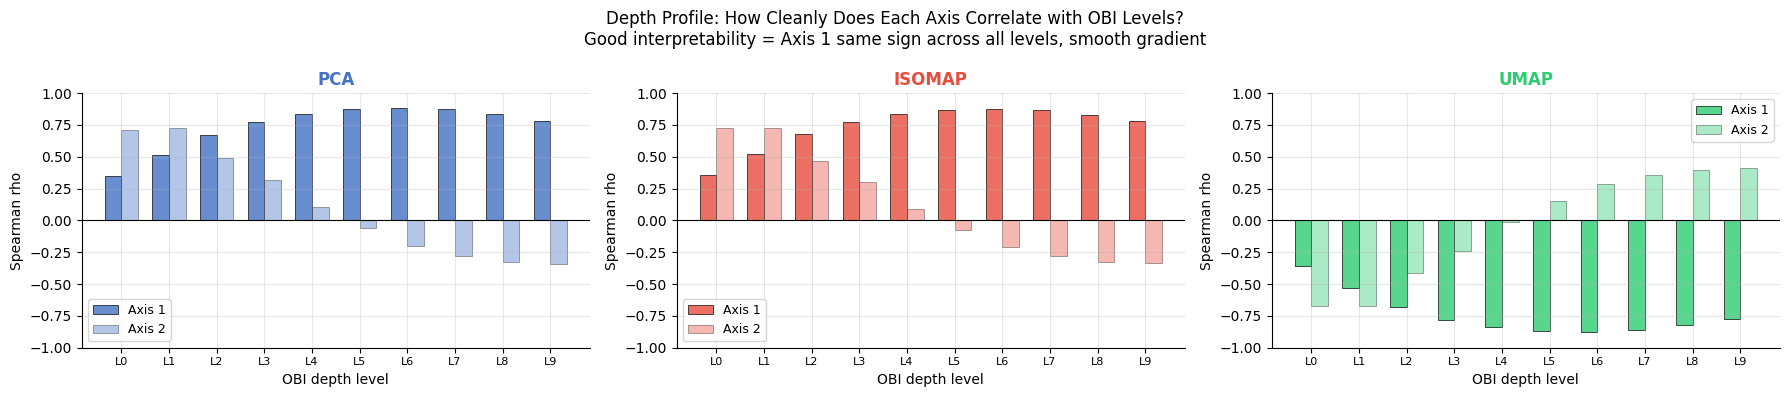

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
x = np.arange(10); w = 0.35

for ax, (method, (Z_calm, _)) in zip(axes, EMBEDDINGS.items()):
    ax1_corrs = [spearmanr(Z_calm[:, 0], X_calm[:, k])[0] for k in range(10)]
    ax2_corrs = [spearmanr(Z_calm[:, 1], X_calm[:, k])[0] for k in range(10)]

    ax.bar(x - w/2, ax1_corrs, w, label='Axis 1', color=COLORS[method],
           alpha=0.8, edgecolor='black', lw=0.6)
    ax.bar(x + w/2, ax2_corrs, w, label='Axis 2', color=COLORS[method],
           alpha=0.4, edgecolor='black', lw=0.6)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'L{k}' for k in range(10)], fontsize=8)
    ax.set_xlabel('OBI depth level')
    ax.set_ylabel('Spearman rho')
    ax.set_title(method, color=COLORS[method], fontweight='bold', fontsize=12)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)

    # Monotonicity check for Axis 1
    signs = np.sign(ax1_corrs)
    monotone = all(s == signs[0] for s in signs)
    smooth = np.diff(ax1_corrs)
    print(f'{method} Axis 1: all same sign={monotone}, '
          f'monotone={all(smooth >= 0) or all(smooth <= 0)}, '
          f'range={min(ax1_corrs):.2f} to {max(ax1_corrs):.2f}')

plt.suptitle('Depth Profile: How Cleanly Does Each Axis Correlate with OBI Levels?\n'
             'Good interpretability = Axis 1 same sign across all levels, smooth gradient',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/verification_depth_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary: Where ISOMAP Actually Earns Its Keep

(Filled in after running the cells above)

| Question | PCA | ISOMAP | UMAP |
|----------|-----|--------|------|
| Euclidean variance at k=2 | ~77% | ~76% | n/a |
| Stress KS separation | ? | ? | ? |
| % stress flagged at 95th pct | ? | ? | ? |
| Axis 1 monotone depth profile | ? | ? | ? |

**Reading guide:**

- **If ISOMAP KS >> PCA KS**: ISOMAP's geodesic structure genuinely spreads the calm distribution differently, pushing stress bars further out. The geometric framework earns its keep for anomaly detection.
- **If KS scores are similar**: Both methods detect stress equally well. The argument for ISOMAP shifts purely to interpretability and pedagogy.
- **UMAP**: Usually gives the cleanest stress/calm separation visually because UMAP aggressively contracts the training distribution into tight clusters. But UMAP's OOS projection is less principled than ISOMAP's Nyström extension — points can land anywhere in the ambient 2D space, so the distance metric is less meaningful.
- **Depth profile**: If ISOMAP Axis 1 is monotone and PCA PC1 is also monotone, the interpretability advantage is marginal. If UMAP axes have no clean correlation pattern, UMAP is useful for visualisation but not for interpretation.
